<a href="https://colab.research.google.com/github/eng-accelerator/Submissions_C5/blob/yashtech-ai-patch-1/Copy_of_multimodal_hf.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install -q transformers datasets accelerate torch torchaudio librosa soundfile

## Sentiment analysis

In [2]:
from transformers import pipeline

sentiment = pipeline("sentiment-analysis")

texts = [
    "I love this workshop!",
    "This is confusing and frustrating",
    "It's okay, not great"
]

for t in texts:
    print(t, "->", sentiment(t))

No model was supplied, defaulted to distilbert/distilbert-base-uncased-finetuned-sst-2-english and revision 714eb0f.
Using a pipeline without specifying a model name and revision in production is not recommended.


config.json:   0%|          | 0.00/629 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

I love this workshop! -> [{'label': 'POSITIVE', 'score': 0.999880313873291}]
This is confusing and frustrating -> [{'label': 'NEGATIVE', 'score': 0.9996371269226074}]
It's okay, not great -> [{'label': 'NEGATIVE', 'score': 0.9818705320358276}]


## Captioning (img -> txt)

In [3]:
from transformers import BlipProcessor, BlipForConditionalGeneration
from PIL import Image
import requests
import torch

processor = BlipProcessor.from_pretrained("Salesforce/blip-image-captioning-base") # BlipProcessor as being analogous to the tokenizer
model = BlipForConditionalGeneration.from_pretrained("Salesforce/blip-image-captioning-base")

url = "https://huggingface.co/datasets/Narsil/image_dummy/raw/main/parrots.png"
image = Image.open(requests.get(url, stream=True).raw).convert("RGB")

inputs = processor(image, return_tensors="pt") # same tokenizer line

out = model.generate(**inputs, max_new_tokens=50) # we expect the model to generate a caption BUT it can't
caption = processor.decode(out[0], skip_special_tokens=True) # why decode function?

print(f"here's the generated caption:\n{caption}")

preprocessor_config.json:   0%|          | 0.00/287 [00:00<?, ?B/s]

The image processor of type `BlipImageProcessor` is now loaded as a fast processor by default, even if the model checkpoint was saved with a slow processor. This is a breaking change and may produce slightly different outputs. To continue using the slow processor, instantiate this class with `use_fast=False`. 


config.json: 0.00B [00:00, ?B/s]

tokenizer_config.json:   0%|          | 0.00/506 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

...

pytorch_model.bin:   0%|          | 0.00/990M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/473 [00:00<?, ?it/s]

The tied weights mapping and config for this model specifies to tie text_decoder.cls.predictions.bias to text_decoder.cls.predictions.decoder.bias, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning
The tied weights mapping and config for this model specifies to tie text_decoder.bert.embeddings.word_embeddings.weight to text_decoder.cls.predictions.decoder.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning
BlipForConditionalGeneration LOAD REPORT from: Salesforce/blip-image-captioning-base
Key                                       | Status     |  | 
------------------------------------------+------------+--+-
text_decoder.bert.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identic

model.safetensors:   0%|          | 0.00/990M [00:00<?, ?B/s]

here's the generated caption:
two birds are standing next to each other birds


## Visual question answering (Image + text -> text)

In [4]:
from transformers import pipeline
from PIL import Image
import requests

vqa = pipeline("visual-question-answering")

url = "https://huggingface.co/datasets/Narsil/image_dummy/raw/main/parrots.png"
image = Image.open(requests.get(url, stream=True).raw)

questions = [
    "How many parrots are there?",
    "What color are the parrots?",
    "Is the mood of the image positive or negative?"
]


print("\n\n"+"=="*20+"\n\n")
print("VQA OUTPUT BELOW")
print("\n\n"+"=="*20+"\n\n")

for q in questions:
    print(f"Q: {q}")
    print("A:", vqa(image=image, question=q))

No model was supplied, defaulted to dandelin/vilt-b32-finetuned-vqa and revision d0a1f6a.
Using a pipeline without specifying a model name and revision in production is not recommended.


config.json: 0.00B [00:00, ?B/s]

pytorch_model.bin:   0%|          | 0.00/470M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/212 [00:00<?, ?it/s]

ViltForQuestionAnswering LOAD REPORT from: dandelin/vilt-b32-finetuned-vqa
Key                                          | Status     |  | 
---------------------------------------------+------------+--+-
vilt.embeddings.text_embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


...

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

preprocessor_config.json:   0%|          | 0.00/251 [00:00<?, ?B/s]

The image processor of type `ViltImageProcessor` is now loaded as a fast processor by default, even if the model checkpoint was saved with a slow processor. This is a breaking change and may produce slightly different outputs. To continue using the slow processor, instantiate this class with `use_fast=False`. 






VQA OUTPUT BELOW




Q: How many parrots are there?
A: [{'score': 0.8621814250946045, 'answer': '2'}, {'score': 0.19997188448905945, 'answer': '3'}, {'score': 0.005999775603413582, 'answer': 'yes'}, {'score': 0.003948522266000509, 'answer': '4'}, {'score': 0.0017056801589205861, 'answer': 'no'}]
Q: What color are the parrots?
A: [{'score': 0.7136160731315613, 'answer': 'gray'}, {'score': 0.6304400563240051, 'answer': 'black and white'}, {'score': 0.35879215598106384, 'answer': 'gray and white'}, {'score': 0.16335797309875488, 'answer': 'black'}, {'score': 0.15588821470737457, 'answer': 'black and gray'}]
Q: Is the mood of the image positive or negative?
A: [{'score': 0.15181663632392883, 'answer': 'no'}, {'score': 0.025610165670514107, 'answer': 'sad'}, {'score': 0.023115184158086777, 'answer': 'calm'}, {'score': 0.010757207870483398, 'answer': 'neither'}, {'score': 0.00995857547968626, 'answer': 'blurry'}]


## ASR (SPEECH to TEXT)

In [5]:
from transformers import AutoProcessor, AutoModelForSpeechSeq2Seq
import torch
import requests
import librosa
import io

model_id = "openai/whisper-small"

processor = AutoProcessor.from_pretrained(model_id)
model = AutoModelForSpeechSeq2Seq.from_pretrained(model_id)

# load audio
audio_url = "https://huggingface.co/datasets/Narsil/asr_dummy/resolve/main/1.flac"
audio_bytes = requests.get(audio_url).content
audio, sr = librosa.load(io.BytesIO(audio_bytes), sr=16000)

# process input
inputs = processor(audio, sampling_rate=16000, return_tensors="pt")

# generate
with torch.no_grad():
    predicted_ids = model.generate(inputs["input_features"])

# decode
transcription = processor.batch_decode(predicted_ids, skip_special_tokens=True)[0]



print("\n\n"+"=="*20+"\n\n")
print(f"The transcription is this: \n\n\n {transcription}")
print("\n\n"+"=="*20+"\n\n")


preprocessor_config.json: 0.00B [00:00, ?B/s]

config.json: 0.00B [00:00, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

...

model.safetensors:   0%|          | 0.00/967M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/479 [00:00<?, ?it/s]

generation_config.json: 0.00B [00:00, ?B/s]

Using custom `forced_decoder_ids` from the (generation) config. This is deprecated in favor of the `task` and `language` flags/config options.
Transcription using a multilingual Whisper will default to language detection followed by transcription instead of translation to English. This might be a breaking change for your use case. If you want to instead always translate your audio to English, make sure to pass `language='en'`. See https://github.com/huggingface/transformers/pull/28687 for more details.
The attention mask is not set and cannot be inferred from input because pad token is same as eos token. As a consequence, you may observe unexpected behavior. Please pass your input's `attention_mask` to obtain reliable results.
A custom logits processor of type <class 'transformers.generation.logits_process.SuppressTokensLogitsProcessor'> has been passed to `.generate()`, but it was also created in `.generate()`, given its parameterization. The custom <class 'transformers.generation.log





The transcription is this: 


  He hoped there would be stew for dinner, turnips and carrots and bruised potatoes and fat mutton pieces to be ladled out in thick, peppered, flour-fattened sauce.






## Small homework: Generating image corresponding to the transcription (audio -> text -> image)

Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.
Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.


Loading weights:   0%|          | 0/479 [00:00<?, ?it/s]





The transcription is this: 


  He hoped there would be stew for dinner, turnips and carrots and bruised potatoes and fat mutton pieces to be ladled out in thick, peppered, flour-fattened sauce.




Generating image from transcription...


model_index.json:   0%|          | 0.00/541 [00:00<?, ?B/s]

Fetching 13 files:   0%|          | 0/13 [00:00<?, ?it/s]

Loading pipeline components...:   0%|          | 0/6 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/196 [00:00<?, ?it/s]

CLIPTextModel LOAD REPORT from: /root/.cache/huggingface/hub/models--runwayml--stable-diffusion-v1-5/snapshots/451f4fe16113bff5a5d2269ed5ad43b0592e9a14/text_encoder
Key                                | Status     |  | 
-----------------------------------+------------+--+-
text_model.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
You have disabled the safety checker for <class 'diffusers.pipelines.stable_diffusion.pipeline_stable_diffusion.StableDiffusionPipeline'> by passing `safety_checker=None`. Ensure that you abide to the conditions of the Stable Diffusion license and do not expose unfiltered results in services or applications open to the public. Both the diffusers team and Hugging Face strongly recommend to keep the safety filter enabled in all public facing circumstances, disabling it only for use-cases that involve analyzing network behavior or auditing its resul

  0%|          | 0/30 [00:00<?, ?it/s]


Image saved to: /content/drive/MyDrive/data/generated_image.png


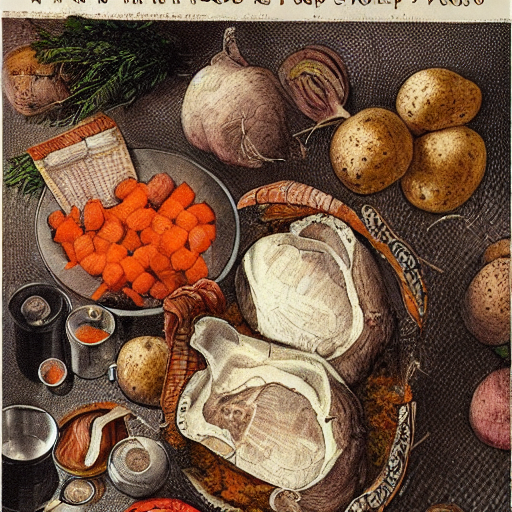

In [8]:
from transformers import AutoProcessor, AutoModelForSpeechSeq2Seq
from diffusers import StableDiffusionPipeline
import torch
import requests
import librosa
import io

# ── 1. TRANSCRIPTION ────────────────────────────────────────────────────────

model_id = "openai/whisper-small"
processor = AutoProcessor.from_pretrained(model_id)
model = AutoModelForSpeechSeq2Seq.from_pretrained(model_id)

# Load audio
audio_url = "https://huggingface.co/datasets/Narsil/asr_dummy/resolve/main/1.flac"
audio_bytes = requests.get(audio_url).content
audio, sr = librosa.load(io.BytesIO(audio_bytes), sr=16000)

# Process & transcribe
inputs = processor(audio, sampling_rate=16000, return_tensors="pt")
with torch.no_grad():
    predicted_ids = model.generate(inputs["input_features"])

transcription = processor.batch_decode(predicted_ids, skip_special_tokens=True)[0]

print("\n\n" + "==" * 20 + "\n\n")
print(f"The transcription is this: \n\n\n {transcription}")
print("\n\n" + "==" * 20 + "\n\n")

# ── 2. TEXT-TO-IMAGE GENERATION ─────────────────────────────────────────────

print("Generating image from transcription...")

# Pick device
device = "cuda" if torch.cuda.is_available() else "cpu"
torch_dtype = torch.float16 if device == "cuda" else torch.float32

# Load Stable Diffusion pipeline
pipe = StableDiffusionPipeline.from_pretrained(
    "runwayml/stable-diffusion-v1-5",
    torch_dtype=torch_dtype,
    safety_checker=None,           # disable NSFW filter if you don't need it
)
pipe = pipe.to(device)

# Optional: speed up inference on CPU
if device == "cpu":
    pipe.enable_attention_slicing()

# Generate image using the transcription as the prompt
image = pipe(
    prompt=transcription,
    num_inference_steps=30,        # higher = better quality, slower
    guidance_scale=7.5,            # how closely to follow the prompt
    height=512,
    width=512,
).images[0]

# Save & display
output_path = "/content/drive/MyDrive/data/generated_image.png"
image.save(output_path)
print(f"\nImage saved to: {output_path}")

# Display inline (works in Jupyter / VS Code notebooks)
try:
    from IPython.display import display
    display(image)
except ImportError:
    pass  # Not in a notebook — image is saved to disk above

In [7]:
from google.colab import drive
drive.mount('/content/drive',force_remount=True)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
